# McGill COMP551, MINI-PROJECT 3: Odd-One-Out Image Groups

Mankush Gandhi (261137633), Armain Labeeb (261023603), Erik Cupsa (261016180)

**Kaggle team name:** Group 88

### Task

The dataset consists of groups of 5 grayscale images (each 32×32 pixels). Within each group, 4 images share a hidden common property and 1 image is the outlier. The task is to predict the index of the outlier image (a 5-class classification problem with labels in {0, 1, 2, 3, 4}). Random chance performance is 20%.

The training set contains 3,000 groups (`x_train.npy`, shape `(3000, 5, 64, 64)`) with corresponding labels (`y_train.npy`, shape `(3000,)`). The test set contains 2,000 groups, split into a public half (1,000 groups with labels provided) and a private half (1,000 groups, labels hidden). Note that the dataset may contain noisy labels.

## Step 0 — Environment Setup

In [18]:
# Mount Google Drive to load the datasets and save outputs.
from google.colab import drive
drive.mount('/content/drive')

import os

# Update PROJECT_DIR here if the folder structure is different.
PROJECT_DIR = '/content/drive/MyDrive/Comp551/mcgill-comp551-winter2026-a3'
DATA_DIR    = os.path.join(PROJECT_DIR, 'datasets')

# Check that all four data files exist before continuing.
print('Checking data files...')
all_ok = True
for fname in ['x_train.npy', 'y_train.npy', 'x_test.npy', 'y_test.npy']:
    path   = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(path)
    print(f'  {"✓" if exists else "✗ MISSING"}  {fname}')
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError('One or more data files are missing.')
print('All data files found.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking data files...
  ✓  x_train.npy
  ✓  y_train.npy
  ✓  x_test.npy
  ✓  y_test.npy
All data files found.


## Step 1 — Data Loading and Exploration

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Load the raw training data.
# Expected shape for x_raw: (3000, 5, 32, 32), representing 3000 groups of 5 grayscale 32x32 images.
# Expected shape for y_raw: (3000,), where each label is the outlier index from 0 to 4.
x_raw = np.load(os.path.join(DATA_DIR, 'x_train.npy'))
y_raw = np.load(os.path.join(DATA_DIR, 'y_train.npy'))

print(f'Training set : {x_raw.shape[0]} groups')
print(f'Image size   : {x_raw.shape[2]}x{x_raw.shape[3]} px, {x_raw.shape[1]} images per group')
print(f'Label values : {np.unique(y_raw)}  (which position is the outlier)')
print(f'Label counts : {np.bincount(y_raw)}  (roughly balanced — good)')
print(f'Pixel range  : [{x_raw.min()}, {x_raw.max()}]  dtype={x_raw.dtype}')


Training set : 3000 groups
Image size   : 32x32 px, 5 images per group
Label values : [0 1 2 3 4]  (which position is the outlier)
Label counts : [616 544 588 645 607]  (roughly balanced — good)
Pixel range  : [0, 255]  dtype=uint8


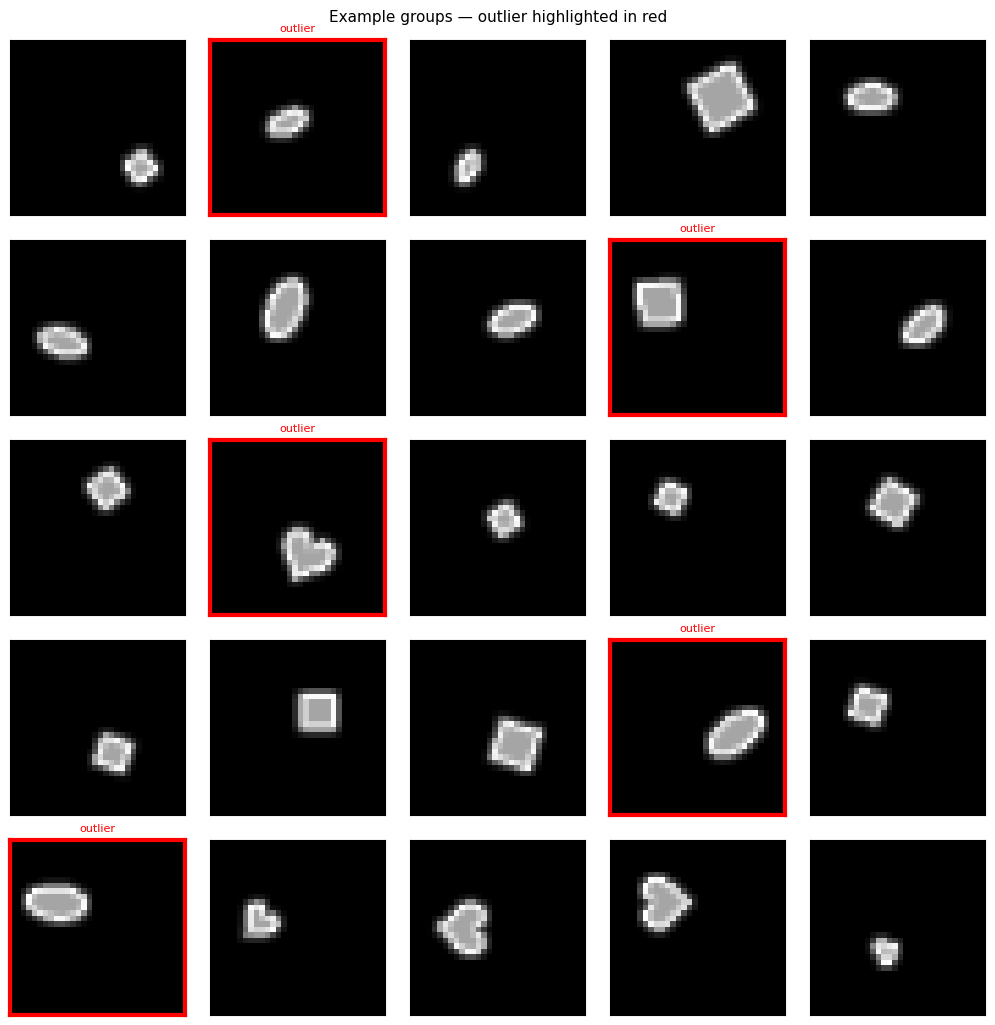

In [20]:
# Plot a few example groups, outliers highlighted with a red border.
def plot_groups(x, y, num_groups=5):
    fig, axes = plt.subplots(num_groups, 5, figsize=(10, 2 * num_groups), layout='constrained')
    fig.suptitle('Example groups — outlier highlighted in red', fontsize=11, y=1.01)
    for i in range(num_groups):
        for j in range(5):
            axes[i, j].imshow(x[i, j], cmap='gray', vmin=0, vmax=255)
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
            if j == y[i]:
                # Use a red border to mark the outlier.
                for sp in axes[i, j].spines.values():
                    sp.set_edgecolor('red'); sp.set_linewidth(3)
                axes[i, j].set_title('outlier', color='red', fontsize=8)
    plt.show()

plot_groups(x_raw, y_raw, num_groups=5)


### Approach Summary

Visual inspection of the data reveals that the hidden common property is **shape category**: circles, ellipses, rectangles, hearts, pentagons, and similar geometric shapes appear across groups. The outlier has a different shape than the other four. Within a group, images of the "same" shape vary substantially in position, size, rotation, and blur level.

A **geometric preprocessing** step centers each shape at the image midpoint, normalizes its bounding box to a fixed size, and aligns its principal axis. This removes spatial variation that is irrelevant to shape identity, freeing the model to focus on learning shape-level features.

The model is a **Siamese depthwise-separable CNN** with shared weights across all 5 image positions. Each image is encoded into an 80-dimensional L2-normalized embedding by a stack of depthwise-separable convolution blocks. Outlier scoring uses a **leave-one-out cosine similarity** mechanism: for each image, cosine similarity is computed against the mean embedding of the other four images. The image with the lowest similarity is predicted as the outlier. A learnable temperature scalar controls logit sharpness.

Depthwise-separable convolutions are used to satisfy the **25,000-parameter constraint**, achieving roughly 8-9x parameter savings over standard convolutions for the same receptive field.

## Step 2 — Geometric Preprocessing

Each image contains a single white shape on a black background, with arbitrary position, size, and orientation. To reduce this irrelevant spatial variation, a deterministic preprocessing step is applied to every image in both the training and test sets before any model training occurs.

For each image, the foreground pixels are identified by thresholding. The center of mass of those pixels is computed and the shape is translated so that its center of mass sits at the image center (16, 16). The bounding box of the shape is measured and the image is scaled so the largest bounding box dimension becomes a fixed 20 pixels. Finally, the principal axis of the shape is estimated via eigendecomposition of the foreground pixel coordinate covariance matrix, and the shape is rotated so that its principal axis aligns horizontally. All three operations (translation, scaling, rotation) are combined into a single affine transform to avoid multiple interpolation passes.

This preprocessing is applied identically to training, validation, and test data.

In [21]:
# Geometric preprocessing - centering and sizing
from scipy import ndimage

def center_and_resize(img, target_bbox=20, threshold=30):
    mask = img > threshold
    if mask.sum() < 5:
        return img

    ys, xs = np.where(mask)
    cy, cx = ys.mean(), xs.mean()

    # Principal axis from covariance of white pixel coordinates
    cov = np.cov(xs - cx, ys - cy)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Angle of the principal axis (eigenvector with largest eigenvalue)
    angle = np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1])

    # Bounding box for scale normalization
    bbox_h = ys.max() - ys.min() + 1
    bbox_w = xs.max() - xs.min() + 1
    max_dim = max(bbox_h, bbox_w)
    if max_dim < 3:
        return img
    scale = target_bbox / max_dim

    # Combined affine: rotate to align principal axis horizontally,
    # scale to target size, and center at (16,16)
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    rotation = np.array([[cos_a, sin_a], [-sin_a, cos_a]])
    scale_matrix = np.array([[1/scale, 0], [0, 1/scale]])
    matrix = rotation @ scale_matrix

    # Map output center (16,16) to input center of mass (cy,cx)
    offset = np.array([cy, cx]) - matrix @ np.array([16.0, 16.0])

    return ndimage.affine_transform(img.astype(np.float32), matrix, offset,
                                     output_shape=(32, 32), order=1, mode='constant', cval=0.0)

def preprocess_dataset(x):
    """Apply centering + size normalization to every image in the dataset."""
    out = np.zeros_like(x, dtype=np.float32)
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            out[i, j] = center_and_resize(x[i, j])
    return out

print('Preprocessing training data...')
x_raw_pp = preprocess_dataset(x_raw)
print('Preprocessing complete')

Preprocessing training data...
Preprocessing complete


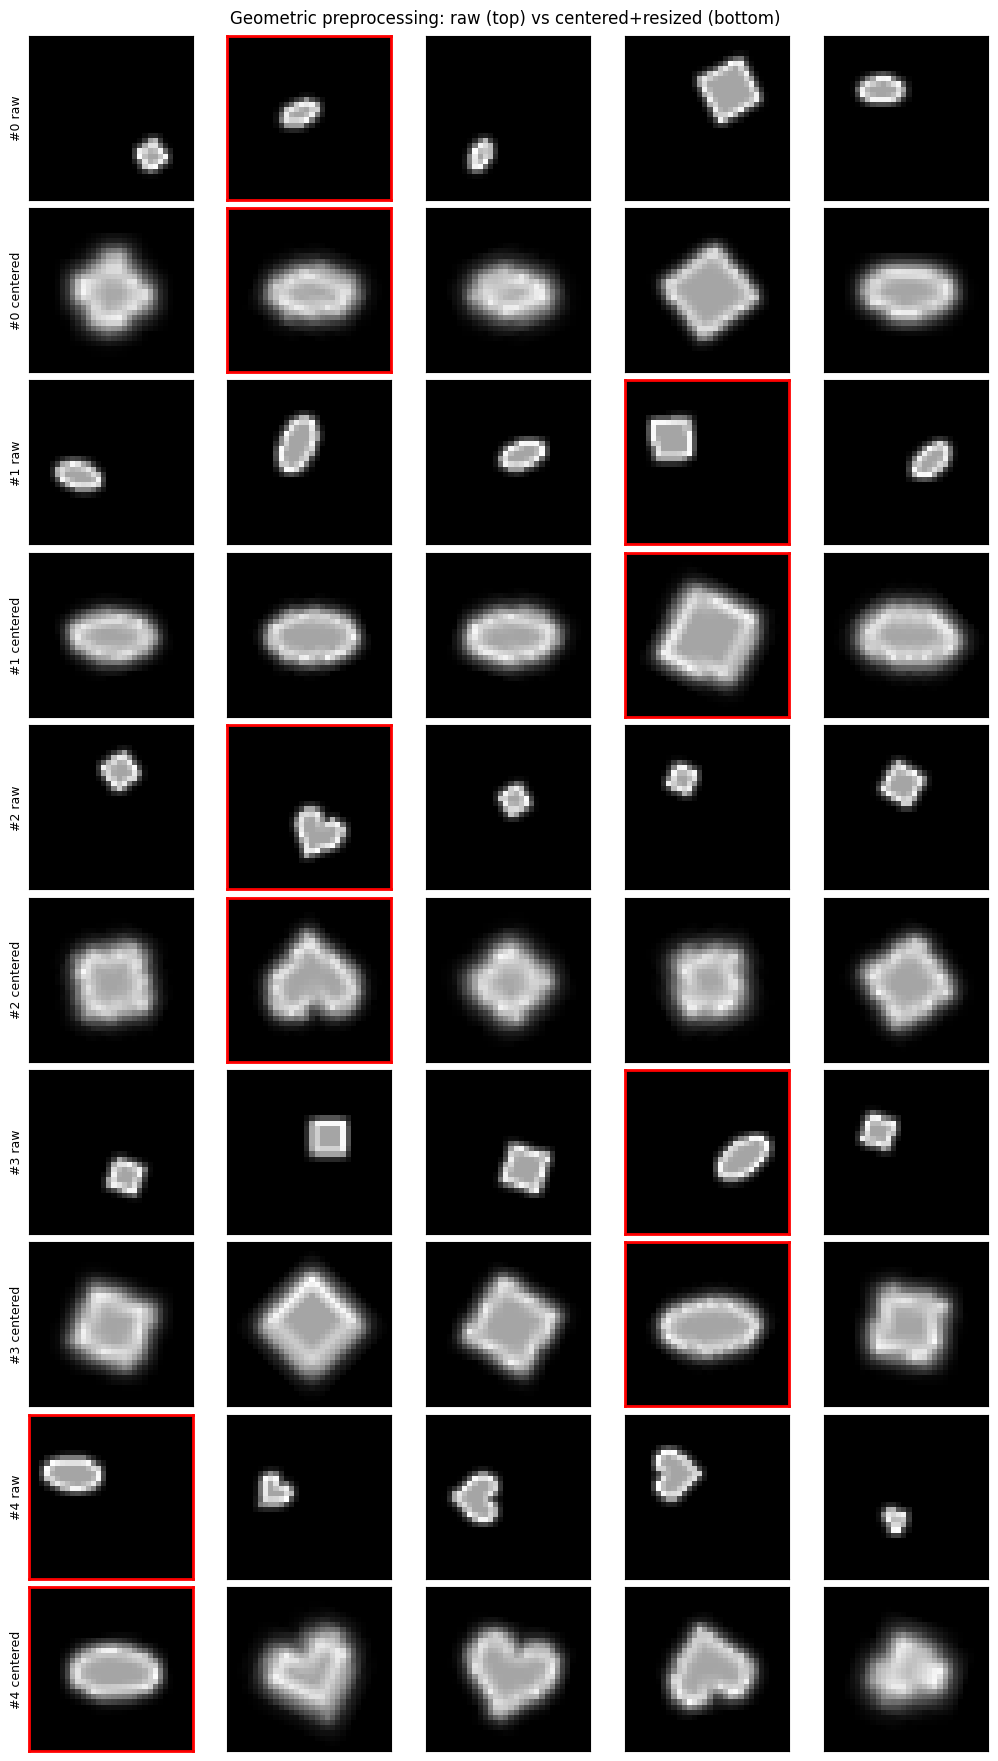

In [22]:
def plot_preprocessing(x_raw, x_pp, y, num_groups=2):
    fig, axes = plt.subplots(num_groups * 2, 5, figsize=(10, 3.5 * num_groups), layout='constrained')
    fig.suptitle('Geometric preprocessing: raw (top) vs centered+resized (bottom)', fontsize=12)
    for g in range(num_groups):
        for j in range(5):
            axes[g*2, j].imshow(x_raw[g, j], cmap='gray', vmin=0, vmax=255)
            axes[g*2, j].set_xticks([]); axes[g*2, j].set_yticks([])
            if j == 0: axes[g*2, j].set_ylabel(f'#{g} raw', fontsize=9)
            axes[g*2+1, j].imshow(x_pp[g, j], cmap='gray', vmin=0, vmax=255)
            axes[g*2+1, j].set_xticks([]); axes[g*2+1, j].set_yticks([])
            if j == 0: axes[g*2+1, j].set_ylabel(f'#{g} centered', fontsize=9)
            if j == y[g]:
                for ax in [axes[g*2, j], axes[g*2+1, j]]:
                    for sp in ax.spines.values():
                        sp.set_edgecolor('red'); sp.set_linewidth(2)
    plt.show()

plot_preprocessing(x_raw, x_raw_pp, y_raw, num_groups=5)

## Step 3 — Model Architecture and Training

### Architecture

The model follows a Siamese design: a single shared CNN encoder processes each of the 5 images independently, producing an 80-dimensional L2-normalized feature vector per image. Shared weights ensure that the model treats all 5 positions identically (permutation equivariance) and that the parameter cost is paid only once.

The encoder consists of an initial standard 3×3 convolution (1→24 channels) followed by five depthwise-separable convolution blocks that progressively expand the channel count (24→24→48→64→80) while downsampling spatially with stride-2 blocks (32×32 → 16×16 → 8×8). Global average pooling collapses the spatial dimensions, yielding an 80-dimensional vector per image. Each convolution is followed by BatchNorm and SiLU activation.

For scoring, a leave-one-out strategy is used: for each image, the mean embedding of the other four images is computed, and cosine similarity is measured between the image and that mean. The outlier should have the lowest similarity. Scores are negated and divided by a learnable temperature scalar so that the outlier position receives the highest logit for cross-entropy loss.

### Data Augmentation

Augmentation is applied independently to each of the 5 images during training only. The transforms include random rotation (±30°), scale jitter (90-100%), shear (±15°), horizontal flip, and vertical flip. The outlier label is invariant to all of these because the hidden property is semantic (shape category), not pixel-level.

### Training Configuration

Training uses AdamW with weight decay 5e-3 and a OneCycleLR schedule (peak LR 1e-3, 15% warmup, cosine annealing). Cross-entropy loss with label smoothing of 0.05 is used to account for potentially noisy labels in the dataset. Gradient norms are clipped at 1.0 to prevent instability during early training. The model achieving the highest validation accuracy is checkpointed and restored at the end of training.

The data is split 85/15 (stratified) into training and validation sets. Normalization statistics (mean and standard deviation) are computed from the training split only.

In [23]:
# Imports and reproducibility setup
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode

# Fix the random seeds for reproducibility.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)           # seeds all GPUs

# Use a GPU if available, then Apple MPS, then CPU.
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')


Using device: cuda


In [24]:
# Train / validation split
# Keep 85% for training and 15% for validation, with stratification so every label remains represented in both splits.
x_tr_raw, x_val_raw, y_tr, y_val = train_test_split(
    x_raw_pp, y_raw, test_size=0.15, random_state=SEED, stratify=y_raw
)
print(f'Train: {len(x_tr_raw)} groups   Val: {len(x_val_raw)} groups')

#  Normalisation
x_tr_f  = x_tr_raw.astype(np.float32)  / 255.0
x_val_f = x_val_raw.astype(np.float32) / 255.0

TRAIN_MEAN = float(x_tr_f.mean())
TRAIN_STD  = float(x_tr_f.std())
print(f'Training mean: {TRAIN_MEAN:.6f}   std: {TRAIN_STD:.6f}')

x_tr_norm  = (x_tr_f  - TRAIN_MEAN) / (TRAIN_STD + 1e-8)
x_val_norm = (x_val_f - TRAIN_MEAN) / (TRAIN_STD + 1e-8)


Train: 2550 groups   Val: 450 groups
Training mean: 0.161380   std: 0.277965


In [25]:
# Dataset class
class OddOneOutDataset(Dataset):
    """
    Wraps a (N, 5, H, W) float32 array of normalised images.

    If a transform is provided, it is applied independently to each of the 5
    images in a group. This keeps augmentation separate for each image;
    the outlier identity does not change regardless of the flip or rotation.
    """
    def __init__(self, images, labels=None, transform=None):
        t = torch.as_tensor(images, dtype=torch.float32)
        if t.ndim == 4:
            t = t.unsqueeze(2)          # Add a channel dimension here: (N, 5, H, W) -> (N, 5, 1, H, W)
        self.images    = t.contiguous()
        self.labels    = None if labels is None else torch.as_tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        group = self.images[idx]        # one group of 5 grayscale images
        if self.transform is not None:
            # Apply the transform to each image in the group separately.
            group = torch.stack([self.transform(img) for img in group], dim=0)
        if self.labels is None:
            return group
        return group, self.labels[idx]


# Augmentation pipeline for training only
# Use only transforms that do not change which image is the outlier.
# Use rotation, scale, and shear so the model is less sensitive to small spatial changes.
train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=30,              # Allow rotation by up to +/-30 degrees
        scale=(0.90, 1.10),      # Allow zoom between 80% and 120%
        shear=15,                # Allow shear by up to 15 degrees
        interpolation=InterpolationMode.BILINEAR,
        fill=0,                  # Fill any empty space with black to match the background
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),   # Vertical flips added in v3
])

# Data loaders
pin_mem = (device.type == 'cuda')  # Enable pin_memory to speed up CPU-to-GPU transfer on CUDA

train_loader = DataLoader(
    OddOneOutDataset(x_tr_norm,  y_tr,  transform=train_transform),
    batch_size=64, shuffle=True,  num_workers=0, pin_memory=pin_mem,
)
val_loader = DataLoader(
    OddOneOutDataset(x_val_norm, y_val, transform=None),  # Leave validation data unaugmented
    batch_size=128, shuffle=False, num_workers=0, pin_memory=pin_mem,
)
print(f'Train batches: {len(train_loader)}   Val batches: {len(val_loader)}')


Train batches: 40   Val batches: 4


In [26]:
# Depthwise-separable convolution block
class DSConvBlock(nn.Module):
    """
    Depthwise-separable convolution block.

    A standard Conv(k×k, Cin→Cout) costs: Cin * Cout * k * k parameters.
    A DSConv replaces it with two cheaper operations:
      1. Depthwise  Conv(k×k, Cin→Cin, groups=Cin) — each channel filtered separately
         Cost: Cin * k * k  parameters
      2. Pointwise  Conv(1×1, Cin→Cout)             — mix channels
         Cost: Cin * Cout   parameters
    Total: Cin*(k*k + Cout) instead of Cin*Cout*k*k  →  ~8-9x cheaper for k=3.

    Each conv is followed by BatchNorm (stabilises training) and SiLU activation
    (smoother gradient than ReLU, works well with normalised inputs).
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            # Use one 3x3 filter per input channel here.
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.SiLU(inplace=True),
            # Mix channels with a 1x1 convolution here.
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


# Main model
class OddOneOutCosineNet(nn.Module):
    """
    Siamese CNN with leave-one-out cosine similarity scoring.

    Why siamese (shared weights)?
      - The outlier can appear in any of the 5 positions — shared weights mean
        the model treats all positions identically (permutation equivariant).
      - We only pay the parameter cost once, not 5 times.

    Encoder: 5 DS conv blocks (24→24→48→64→80 channels) + AdaptiveAvgPool
             → 80-dim vector per image → L2-normalised.

    Scoring: For each image i, compute cosine similarity to the mean embedding
             of the other 4 images. Low similarity = likely the outlier.
             Negate so that the outlier gets the highest logit for CrossEntropyLoss.

    Temperature: A single learnable scalar τ scales the logits. Starting near 0.07
                 (standard value from contrastive learning). Clamped to [0.001, 10].
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            # Standard convolution to go from 1 channel to 24 feature maps.
            nn.Conv2d(1, 24, 3, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.SiLU(inplace=True),
            # Stack DS blocks that expand channels and downsample where needed.
            DSConvBlock(24, 24, stride=1),   # Keep the spatial size at 32x32 here
            DSConvBlock(24, 48, stride=2),   # Downsample to 16x16 and expand from 24 to 48 channels here
            DSConvBlock(48, 64, stride=1),   # Keep the spatial size at 16x16 here
            DSConvBlock(64, 80, stride=2),   # Downsample to 8x8 and expand from 64 to 80 channels here
            DSConvBlock(80, 80, stride=1),   # Keep the spatial size at 8x8 here
            # Collapse the spatial dimensions so each image ends up as an 80-dimensional vector.
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )
        # Learn log(temperature) so the temperature stays positive.
        self.log_temperature = nn.Parameter(
            torch.tensor(np.log(0.07), dtype=torch.float32)
        )

    def forward(self, x):
        b, k, c, h, w = x.shape   # Unpack this as b=batch, k=5 images, c=1, h=w=32

        # 1. Encode all 5 images in one batched call.
        z = self.encoder(x.view(b * k, c, h, w))    # shape: (B*5, 80)
        z = F.normalize(z, p=2, dim=-1)              # L2-normalise each embedding
        z = z.view(b, k, -1)                         # shape: (B, 5, 80)

        # 2. Compute the leave-one-out mean for each image using the other 4.
        #    Subtract z_i from the total sum, then divide by (k - 1).
        loo_mean = (z.sum(dim=1, keepdim=True) - z) / (k - 1)   # shape: (B, 5, 80)

        # 3. Measure how similar each image is to the group average.
        #    If similarity is high, that image is probably not the outlier.
        sim = F.cosine_similarity(z, loo_mean, dim=-1, eps=1e-8)   # shape: (B, 5)

        # 4. Negate and scale the scores so the outlier gets the highest logit.
        temperature = torch.exp(self.log_temperature).clamp(1e-3, 10.0)
        return -sim / temperature   # shape: (B, 5)


# Instantiate the model and move it to the selected device.
model = OddOneOutCosineNet().to(device)
print('Model created successfully.')


Model created successfully.


In [27]:
# Print the number of trainable parameters

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
assert total_params <= 25_000, f'Model too large! {total_params:,} > 25,000'
print('Parameter limit check PASSED (≤ 25,000)\n')

print('Breakdown by submodule:')
for name, mod in model.named_children():
    n = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    print(f'  {name:20s}: {n:,} params')


Total trainable parameters: 19,817
Parameter limit check PASSED (≤ 25,000)

Breakdown by submodule:
  encoder             : 19,816 params


In [28]:
# Training loop
EPOCHS  = 250   # Increased from 90 in v2
MAX_LR  = 1e-3

# Use CrossEntropyLoss with label_smoothing=0.05
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# Use AdamW so weight decay stays decoupled from the gradient update.
optimizer = optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=5e-3)

# Use OneCycleLR so the learning rate ramps up for the first 15% of training, then cosine-decays
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.15,          # Use the first 15% of steps for warmup
    anneal_strategy='cos',
    div_factor=20.0,         # Start at MAX_LR / 20
    final_div_factor=500.0,  # End at MAX_LR / 500
)

# Track these metrics for the learning-curve plots later.
best_val_loss  = np.inf
best_val_acc   = 0
best_epoch     = 0
best_state     = copy.deepcopy(model.state_dict())
non_blocking   = (device.type == 'cuda')
train_acc_hist = []
val_acc_hist   = []
loss_hist      = []
val_loss_hist  = []

for epoch in range(1, EPOCHS + 1):
    # Training phase
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=non_blocking)
        yb = yb.to(device, non_blocking=non_blocking)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()

        # Clip the gradient norm at 1.0
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()   # Step OneCycleLR every batch, not every epoch

        tr_loss    += loss.item() * yb.size(0)
        tr_correct += (logits.argmax(1) == yb).sum().item()
        tr_total   += yb.size(0)

    tr_loss /= tr_total
    tr_acc   = 100.0 * tr_correct / tr_total

    # Validation phase
    model.eval()
    val_correct, val_total = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=non_blocking)
            yb = yb.to(device, non_blocking=non_blocking)
            logits = model(xb)
            val_loss += criterion(logits, yb).item() * yb.size(0)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total   += yb.size(0)

    val_loss /= val_total
    val_acc = 100.0 * val_correct / val_total

    train_acc_hist.append(tr_acc)
    val_acc_hist.append(val_acc)
    loss_hist.append(tr_loss)
    val_loss_hist.append(val_loss)

    # Model Checkpointing
    if val_acc > best_val_acc:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_epoch   = epoch
        best_state   = copy.deepcopy(model.state_dict())
        marker = ' ◀ best'
    else:
        marker = ''

    lr_now   = optimizer.param_groups[0]['lr']
    temp_now = torch.exp(model.log_temperature).item()

    # Log output
    if epoch % 10 == 0 or epoch == 1 or marker:
        print(
            f'Epoch {epoch:03d}/{EPOCHS} | '
            f'tr_loss {tr_loss:.4f} | val_loss {val_loss:.4f} | '
            f'train_acc {tr_acc:.2f}% | val_acc {val_acc:.2f}% | '
            f'lr {lr_now:.2e} | temp {temp_now:.4f}{marker}'
        )

# Restore the weights from the best validation epoch.
model.load_state_dict(best_state)
print(f'\nRestored best model from epoch {best_epoch}  (val acc = {best_val_acc:.2f}%, val loss = {best_val_loss:.4f}%)')


Epoch 001/250 | tr_loss 1.6210 | val_loss 1.5892 | train_acc 29.02% | val_acc 34.67% | lr 5.17e-05 | temp 0.0701 ◀ best
Epoch 002/250 | tr_loss 1.5098 | val_loss 1.4453 | train_acc 35.76% | val_acc 40.67% | lr 5.67e-05 | temp 0.0702 ◀ best
Epoch 003/250 | tr_loss 1.4050 | val_loss 1.3512 | train_acc 46.35% | val_acc 48.67% | lr 6.49e-05 | temp 0.0701 ◀ best
Epoch 004/250 | tr_loss 1.2808 | val_loss 1.2441 | train_acc 55.22% | val_acc 55.33% | lr 7.65e-05 | temp 0.0699 ◀ best
Epoch 005/250 | tr_loss 1.1781 | val_loss 1.1905 | train_acc 59.14% | val_acc 57.56% | lr 9.11e-05 | temp 0.0697 ◀ best
Epoch 006/250 | tr_loss 1.1166 | val_loss 1.1713 | train_acc 62.31% | val_acc 57.78% | lr 1.09e-04 | temp 0.0696 ◀ best
Epoch 008/250 | tr_loss 1.0603 | val_loss 1.1458 | train_acc 64.78% | val_acc 59.78% | lr 1.53e-04 | temp 0.0696 ◀ best
Epoch 009/250 | tr_loss 1.0489 | val_loss 1.1266 | train_acc 65.88% | val_acc 60.22% | lr 1.79e-04 | temp 0.0697 ◀ best
Epoch 010/250 | tr_loss 1.0168 | val_los

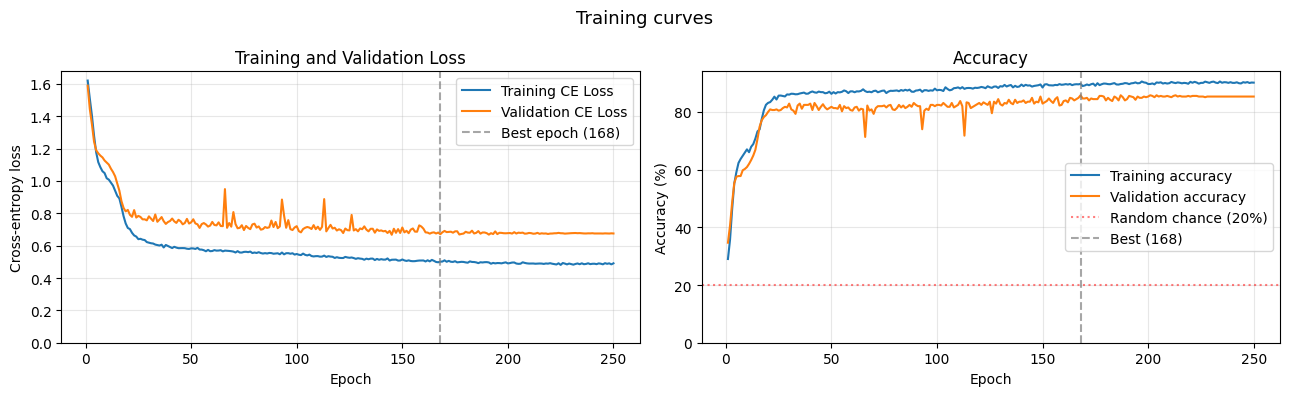

Best validation accuracy: 85.78%
Validation loss at checkpoint: 0.6709


In [29]:
# Learning curves
epochs_ran = list(range(1, len(train_acc_hist) + 1))
fig, axes  = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training curves', fontsize=13)

axes[0].plot(epochs_ran, loss_hist, linewidth=1.5, label='Training CE Loss')
axes[0].plot(epochs_ran, val_loss_hist, linewidth=1.5, label='Validation CE Loss')
axes[0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training and Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(bottom=0)

axes[1].plot(epochs_ran, train_acc_hist, linewidth=1.5, label='Training accuracy')
axes[1].plot(epochs_ran, val_acc_hist, linewidth=1.5, label='Validation accuracy')
axes[1].axhline(20, color='red',  linestyle=':', alpha=0.5, label='Random chance (20%)')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()
print(f'Best validation accuracy: {best_val_acc:.2f}%')
print(f'Validation loss at checkpoint: {best_val_loss:.4f}')


## Step 4 — Test Set Evaluation

The same geometric preprocessing and normalization applied to training data is applied to the test set. Test-Time Augmentation (TTA) averages logits across 4 views of each group (original, horizontal flip, vertical flip, and both flips combined). Since the outlier label is flip-invariant, all views are equally valid. Averaging reduces prediction variance at zero additional training cost.

Accuracy is reported on the public test half (1,000 groups with provided labels), which matches the public Kaggle leaderboard score.

In [30]:
from sklearn.metrics import accuracy_score

# Load test data
x_test_raw  = np.load(os.path.join(DATA_DIR, 'x_test.npy'))    # Expected shape: (2000, 5, 32, 32) with uint8 pixels
y_test_half = np.load(os.path.join(DATA_DIR, 'y_test.npy'))    # Expected shape: (1000,) for the public-half labels

# Preprocess
x_test_raw = preprocess_dataset(x_test_raw)

print(f'Test set      : {x_test_raw.shape[0]} groups total')
print(f'Public half   : {len(y_test_half)} groups (labels provided)')
print(f'Private half  : {x_test_raw.shape[0] - len(y_test_half)} groups (labels hidden until deadline)')

# Apply the same normalisation used during training.
x_test_norm = (x_test_raw.astype(np.float32) / 255.0 - TRAIN_MEAN) / (TRAIN_STD + 1e-8)
print(f'Test normalised with training mean={TRAIN_MEAN:.4f}, std={TRAIN_STD:.4f}')


Test set      : 2000 groups total
Public half   : 1000 groups (labels provided)
Private half  : 1000 groups (labels hidden until deadline)
Test normalised with training mean=0.1614, std=0.2780


In [31]:
# TTA helper functions

def get_logits(model, x_np, device, batch_size=128):
    """
    Run a single forward pass on the entire dataset.

    x_np   : (N, 5, H, W) float32, already normalised
    returns: (N, 5) tensor of raw logits on CPU

    A temporary DataLoader avoids loading everything
    onto the GPU at once, which would run out of memory on large datasets.
    """
    model.eval()
    # Add a channel dimension here: (N, 5, H, W) -> (N, 5, 1, H, W)
    t  = torch.as_tensor(x_np, dtype=torch.float32).unsqueeze(2)
    ds = torch.utils.data.TensorDataset(t)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for (xb,) in dl:
            preds.append(model(xb.to(device)).cpu())
    return torch.cat(preds)   # shape: (N, 5)


def predict_tta(model, x_np, device, batch_size=128):
    """
    Test-Time Augmentation: average logits over 4 flipped versions.

    Each flip is a valid view of the same group. Averaging
    the model's confidence across multiple views reduces the variance of
    the prediction, similar to how an ensemble of models would work — but
    at zero extra training cost.

    x_np   : (N, 5, H, W) float32, already normalised
    returns: (N,) int numpy array of predicted outlier indices
    """
    # Start with the original view.
    logits  = get_logits(model, x_np, device, batch_size)
    # Add a left-right flip, where the last HxW axis is W.
    logits += get_logits(model, x_np[:, :, :, ::-1].copy(), device, batch_size)
    # Add a top-bottom flip, where the second-to-last axis is H.
    logits += get_logits(model, x_np[:, :, ::-1, :].copy(), device, batch_size)
    # Add the version with both flips.
    logits += get_logits(model, x_np[:, :, ::-1, ::-1].copy(), device, batch_size)
    # Do not divide by 4 because argmax of the sum is the same as argmax of the average.
    return logits.argmax(dim=1).numpy()


In [32]:
# Run evaluation

# Public-half accuracy without TTA and with TTA
preds_no_tta = get_logits(model, x_test_norm[:len(y_test_half)], device).argmax(1).numpy()
acc_no_tta   = accuracy_score(y_test_half, preds_no_tta)
print(f'Public accuracy (no TTA)  : {acc_no_tta * 100:.2f}%')

all_predictions_tta = predict_tta(model, x_test_norm, device)
public_test_predictions    = all_predictions_tta[:len(y_test_half)]
public_test_accuracy       = accuracy_score(y_test_half, public_test_predictions)
print(f'Public accuracy (with TTA): {public_test_accuracy * 100:.2f}%')
print(f'TTA improvement           : +{(public_test_accuracy - acc_no_tta)*100:.2f}%')


Public accuracy (no TTA)  : 70.30%
Public accuracy (with TTA): 70.90%
TTA improvement           : +0.60%


## Step 5 — Error Analysis

To understand the model's failure modes, predictions on the public test half are compared against ground truth. The confusion distribution across labels is reported, and a sample of misclassified and correctly classified groups are visualized. This analysis reveals whether errors are concentrated on particular label positions or shape types, and whether noisy ground-truth labels contribute to apparent misclassifications.

Correct: 703/1000,  Wrong: 297/1000

Confusion (true label distribution for wrong predictions):
  Label 0: true 65 times, predicted 66 times
  Label 1: true 60 times, predicted 58 times
  Label 2: true 50 times, predicted 58 times
  Label 3: true 62 times, predicted 62 times
  Label 4: true 60 times, predicted 53 times
Incorrectly classified groups:


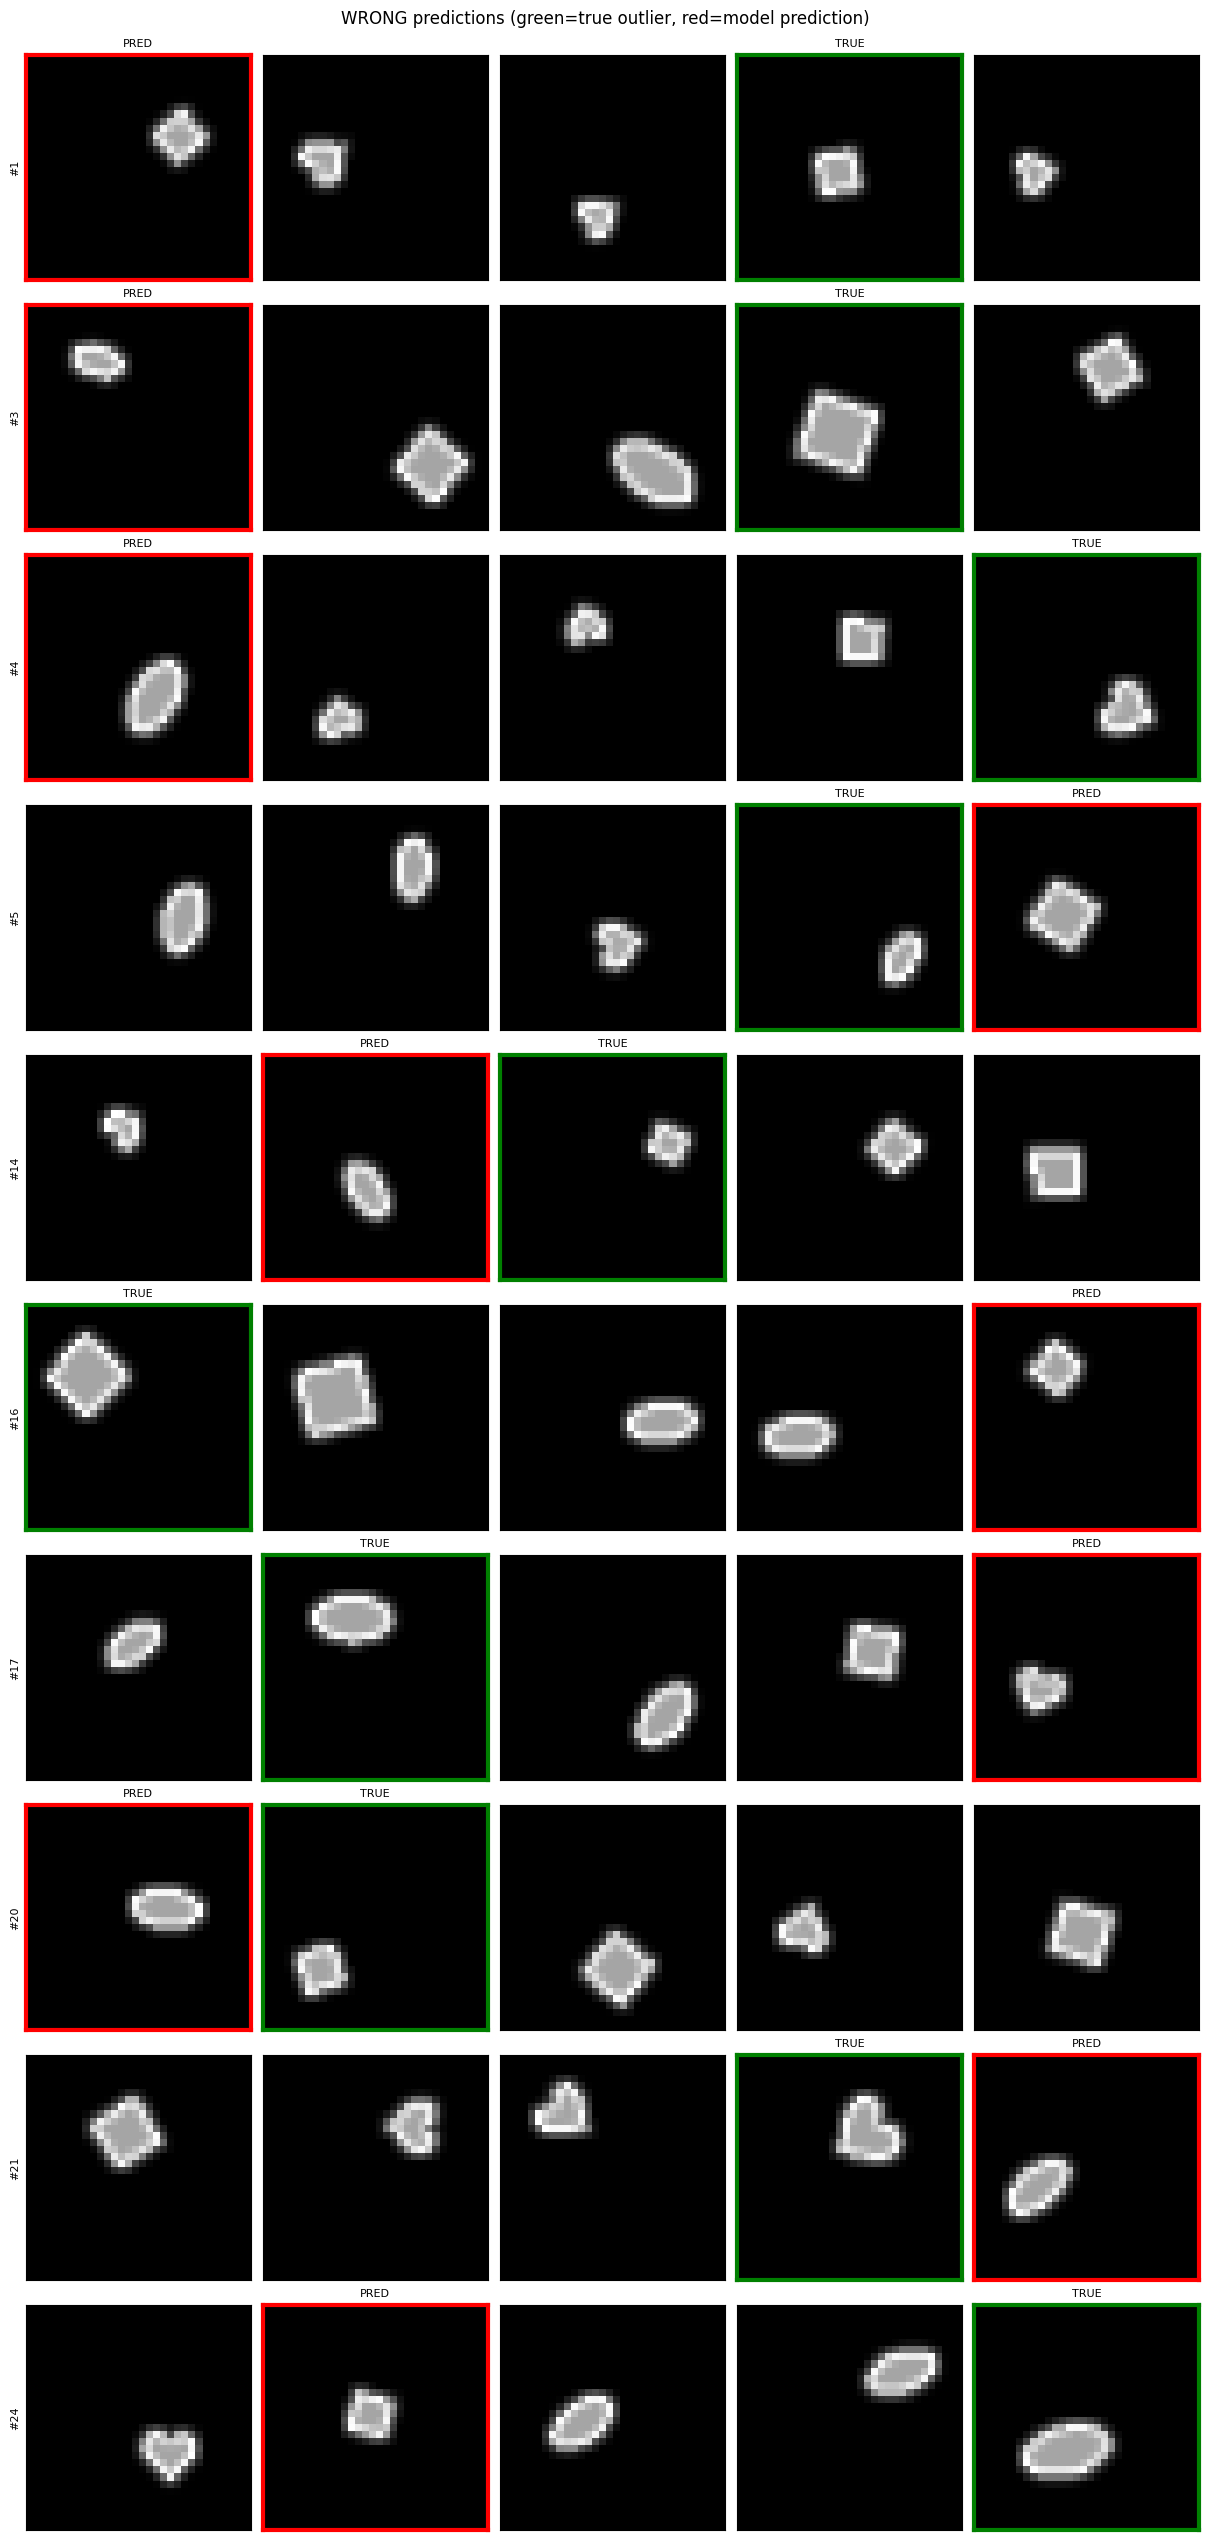

CORRECTLY classified groups:


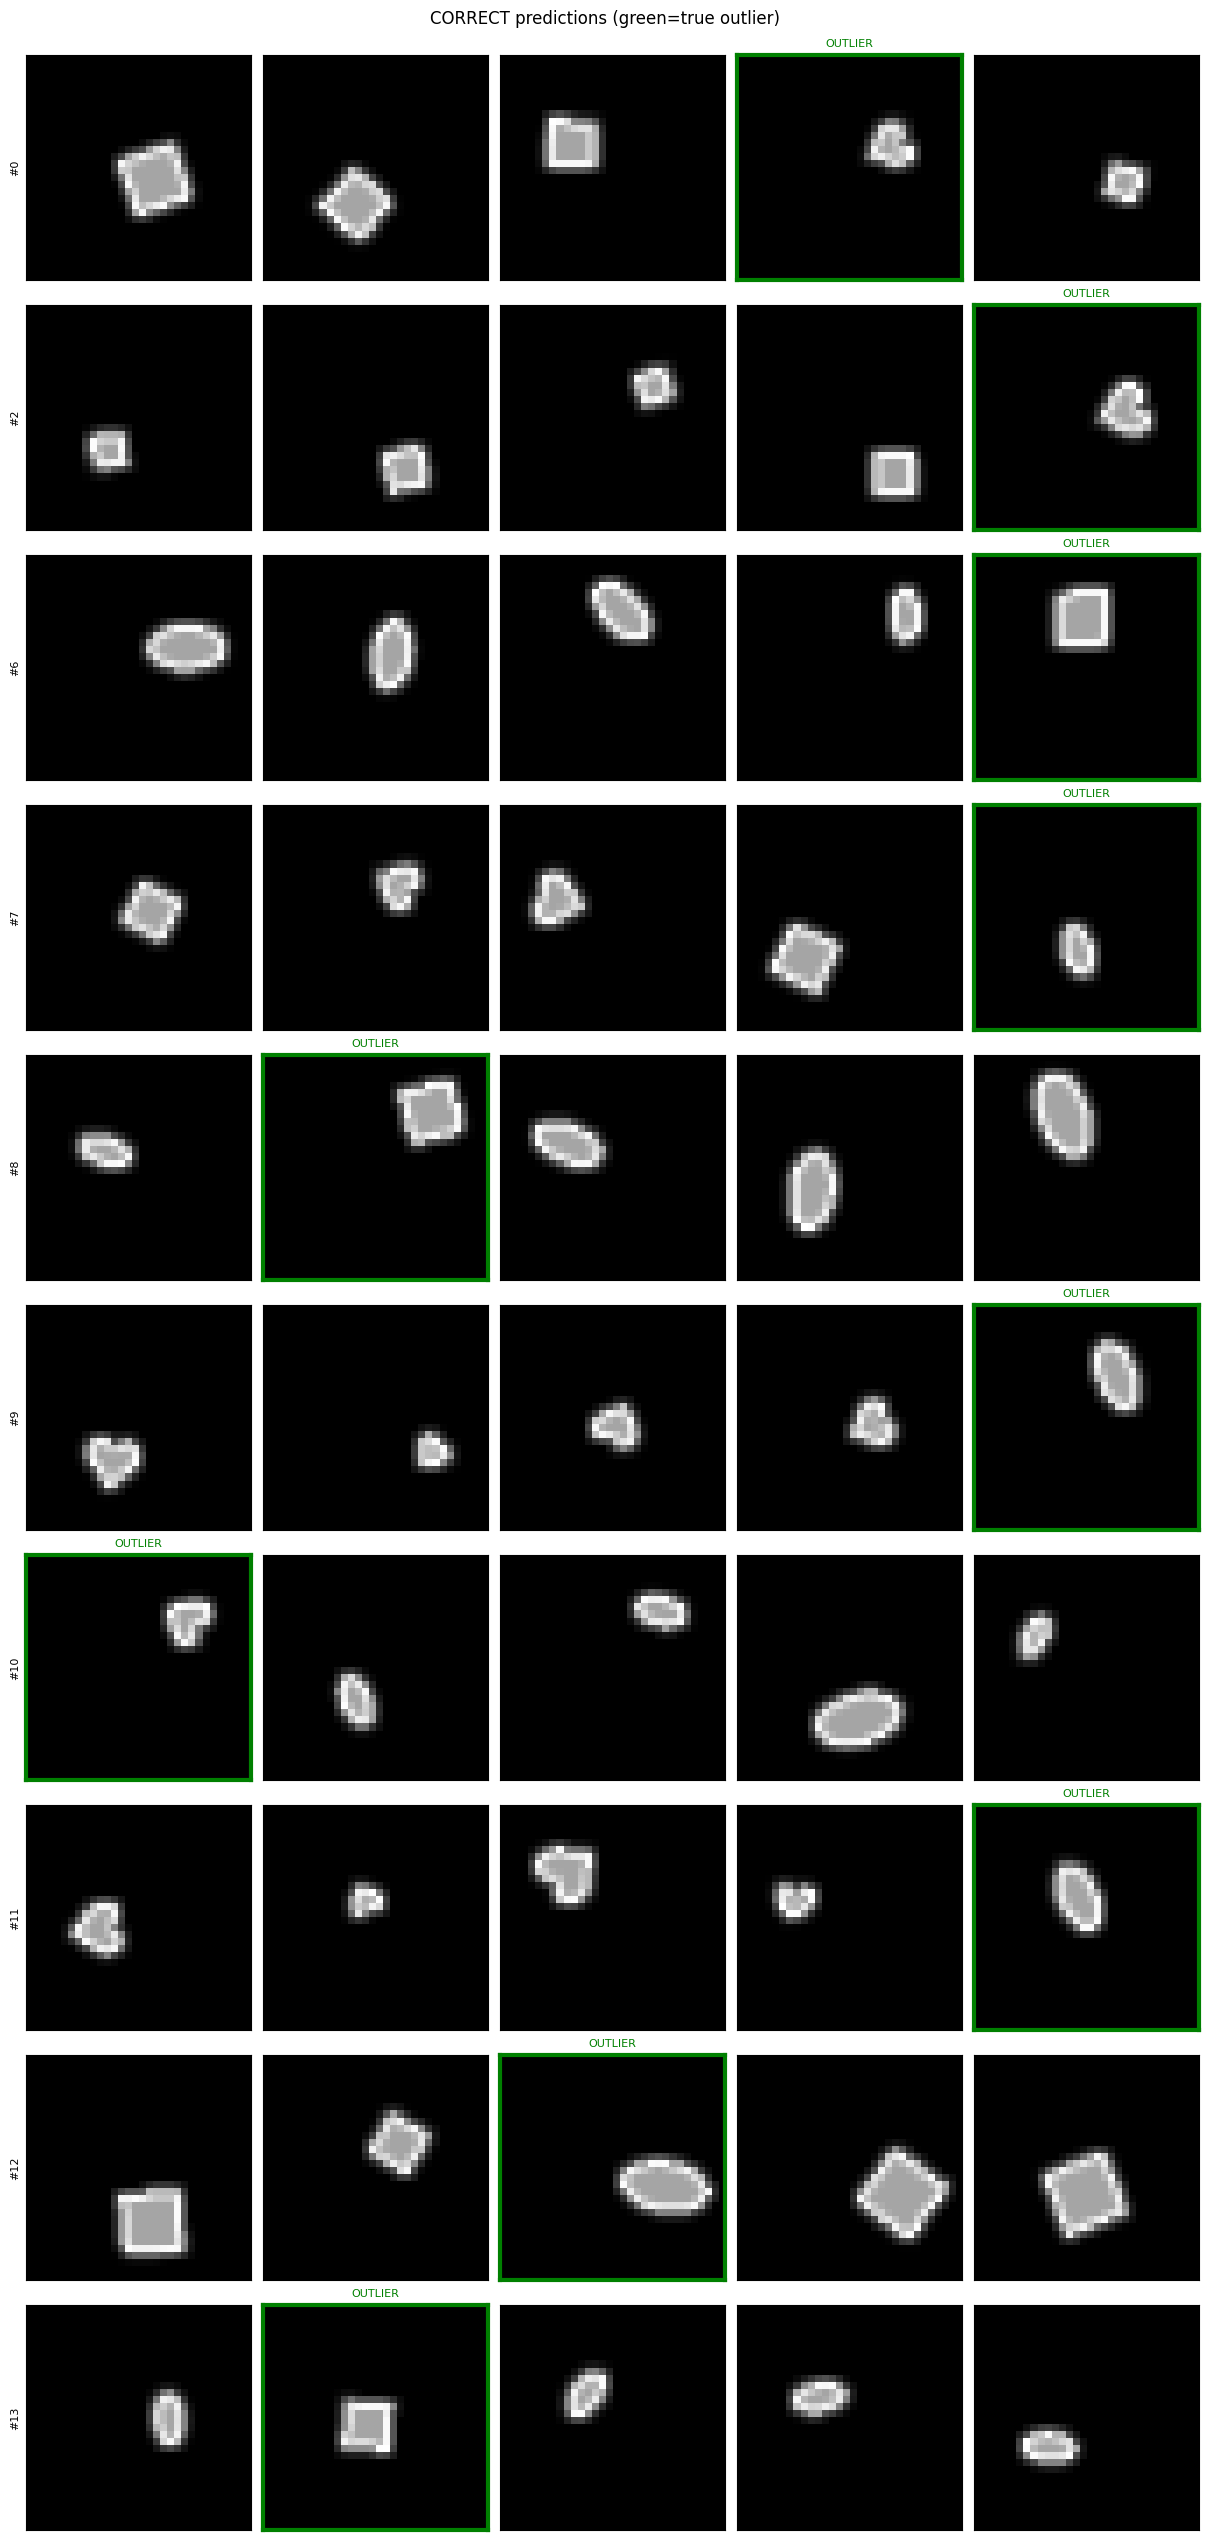

In [33]:
# ── Error analysis ────────────────────────────────────────────────────────────
preds = get_logits(model, x_test_norm[:1000], device).argmax(1).numpy()
correct_mask = (preds == y_test_half)
wrong_mask = ~correct_mask
print(f'Correct: {correct_mask.sum()}/1000,  Wrong: {wrong_mask.sum()}/1000\n')

# Wrong predictions
wrong_preds = preds[wrong_mask]
wrong_true  = y_test_half[wrong_mask]
print('Confusion (true label distribution for wrong predictions):')
for label in range(5):
    n_true = (wrong_true == label).sum()
    n_pred = (wrong_preds == label).sum()
    print(f'  Label {label}: true {n_true} times, predicted {n_pred} times')

# Visualise some wrong predictions vs some correct ones
x_test_vis = np.load(os.path.join(DATA_DIR, 'x_test.npy'))[:1000]

print('Incorrectly classified groups:')
wrong_indices = np.where(wrong_mask)[0][:10]
fig, axes = plt.subplots(len(wrong_indices), 5, figsize=(12, 2.5 * len(wrong_indices)), layout='constrained')
for row, idx in enumerate(wrong_indices):
    for col in range(5):
        axes[row, col].imshow(x_test_vis[idx, col], cmap='gray', vmin=0, vmax=255)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        title = ''
        if col == y_test_half[idx]:
            for sp in axes[row, col].spines.values():
                sp.set_edgecolor('green'); sp.set_linewidth(3)
            title = 'TRUE'
        if col == preds[idx]:
            for sp in axes[row, col].spines.values():
                sp.set_edgecolor('red'); sp.set_linewidth(3)
            title += (' ' if title else '') + 'PRED'
        axes[row, col].set_title(title, fontsize=8)
    axes[row, 0].set_ylabel(f'#{idx}', fontsize=8)
fig.suptitle('WRONG predictions (green=true outlier, red=model prediction)', y=1.01)
plt.show()

print('CORRECTLY classified groups:')
right_indices = np.where(correct_mask)[0][:10]
fig, axes = plt.subplots(len(right_indices), 5, figsize=(12, 2.5 * len(right_indices)), layout='constrained')
for row, idx in enumerate(right_indices):
    for col in range(5):
        axes[row, col].imshow(x_test_vis[idx, col], cmap='gray', vmin=0, vmax=255)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if col == y_test_half[idx]:
            for sp in axes[row, col].spines.values():
                sp.set_edgecolor('green'); sp.set_linewidth(3)
            axes[row, col].set_title('OUTLIER', fontsize=8, color='green')
    axes[row, 0].set_ylabel(f'#{idx}', fontsize=8)
fig.suptitle('CORRECT predictions (green=true outlier)', y=1.01)
plt.show()

### Design Decisions and Ablations

Several alternatives were explored during development:

- **Dropout regularization** (`Dropout2d` with p=0.15 between DS blocks) was tested but degraded performance. The model has limited capacity at 25k parameters, and dropout further restricted its ability to learn.
- **Pairwise cosine similarity scoring** (computing individual similarity between all 10 image pairs instead of comparing each image to the leave-one-out mean) was tested but produced worse results than the leave-one-out mean approach.
- **A shallower, wider encoder** (3 DS blocks with channels 32→64→96 instead of 5 blocks at 24→24→48→64→80) was tested but did not improve performance.
- **K-fold cross-validation with ensemble** (5-fold, averaging logits from 5 models at test time) was tested. Each fold achieved ~85% validation accuracy, but the ensemble scored lower on the public test set than a single model, suggesting the train-test gap is driven by distribution differences rather than overfitting. It also required significant compute and time for training and so was abandoned.
- **Test-Time Augmentation** with 4 views (original + 3 flip combinations) provides a modest variance reduction at inference time with no extra training cost. Expanding to 16 views (rotations × flips) did not yield meaningful improvement.
- **Geometric preprocessing** (centering, size normalization, and principal-axis alignment) improved public test accuracy by approximately 3 percentage points over the raw-image baseline, confirming that removing irrelevant spatial variation helps the model generalize.

## Step 6 — Kaggle Submission

Predictions are generated for all 2,000 test groups and exported in the required CSV format (columns: `Id`, `Category`). The first 1,000 predictions correspond to the public leaderboard; the remaining 1,000 correspond to the private leaderboard revealed after the deadline.

In [34]:
import pandas as pd

def generate_csv_kaggle(predictions, filename='predicted_labels.csv'):
    """
    Save predictions in the format Kaggle expects:
      Id       — row index as a string (0, 1, 2, ...)
      Category — predicted outlier position (0–4) as a string

    We predict on all 2000 test groups. The first 1000 score on the
    public leaderboard; the last 1000 score on the private leaderboard
    (revealed after the deadline).
    """
    df = pd.DataFrame({
        'Id':       np.arange(len(predictions)).astype(str),
        'Category': predictions.astype(str)
    })
    df.to_csv(filename, index=False)
    print(f'Saved {len(predictions)} predictions to {filename}')
    print('First 5 rows:')
    print(df.head())


csv_path = os.path.join(PROJECT_DIR, 'predicted_labels.csv')
generate_csv_kaggle(all_predictions_tta, csv_path)

# Direct download from Colab.
from google.colab import files
files.download(csv_path)


Saved 2000 predictions to /content/drive/MyDrive/Comp551/mcgill-comp551-winter2026-a3/predicted_labels.csv
First 5 rows:
  Id Category
0  0        3
1  1        0
2  2        4
3  3        0
4  4        0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>